In [41]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random
import math
import gymnasium as gym
from gymnasium.core import ObservationWrapper
from IPython.display import clear_output

In [24]:
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    os.environ["DISPLAY"] = ":1"

In [25]:
class QLearningAgent:
    def __init__(self, alpha, epsilon, discount, get_legal_actions):
        self.get_legal_actions = get_legal_actions
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0.0))
        self.alpha = alpha
        self.epsilon = epsilon
        self.discount = discount

    def get_qvalue(self, state, action):
        return self._qvalues[state][action]
    
    def set_qvalue(self, state, action, value):
        self._qvalues[state][action] = value

    def get_value(self, state):
        possible_actions = self.get_legal_actions(state)
        if(len(possible_actions) == 0):
            return 0.0
        value = max([self.get_qvalue(state, action) for action in possible_actions])
        return value
    
    def update(self, state, action, reward, next_state):
        gamma = self.discount
        learning_rate = self.alpha
        old_q_value = self.get_qvalue(state, action)
        new_q_value = (1 - learning_rate) * old_q_value + learning_rate * (reward + gamma * self.get_value(next_state))
        self.set_qvalue(state, action, new_q_value)

    def get_best_action(self, state):
        possible_actions = self.get_legal_actions(state)
        if len(possible_actions) == 0:
            return None
        actions = [self.get_qvalue(state, action) for action in possible_actions]
        argmax = np.argmax(actions)
        best_action = possible_actions[argmax]
        return best_action    
    
    def get_action(self, state):
        possible_actions = self.get_legal_actions(state)
        if len(possible_actions) == 0:
            return None
        if(random.random() < self.epsilon):
            return random.choice(possible_actions)
        
        return self.get_best_action(state)
        

In [26]:
env = gym.make("Taxi-v3")
n_actions = env.action_space.n

agent = QLearningAgent(alpha=0.5, epsilon=0.25, discount=0.99, 
                       get_legal_actions = lambda s : range(n_actions))

In [27]:
def play_and_train(env : gym.Env, agent : QLearningAgent, t_max = 10**4):
    total_reward = 0
    s, _ = env.reset()
    for t in range(t_max):
        a = agent.get_action(s)
        
        next_s, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated
        
        agent.update(s, a, r, next_s)
        s = next_s
        total_reward += r
        if done:
            break

    return total_reward

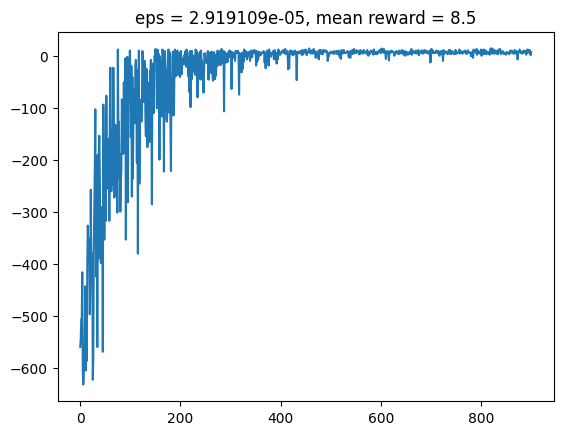

In [28]:
rewards = []
for i in range(1000):
    rewards.append(play_and_train(env, agent))
    agent.epsilon *= 0.99
    if i % 100 == 0:
        clear_output(True)
        plt.title(f'eps = {agent.epsilon:e}, mean reward = {np.mean(rewards[-10:]):.1f}')
        plt.plot(rewards)
        plt.show()

first state:  [ 0.04043228  0.02687954 -0.01914504 -0.04621844]


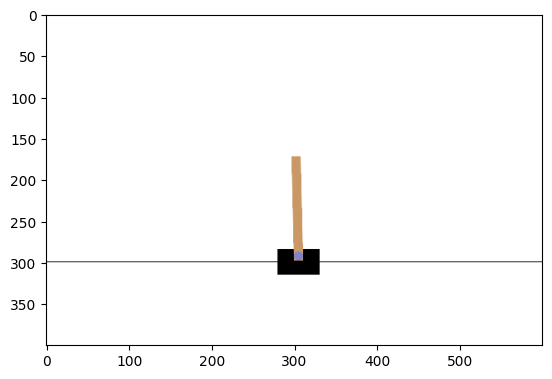

In [36]:
def make_env():
    return gym.make('CartPole-v0', render_mode='rgb_array').env

env = make_env()
n_actions = env.action_space.n
print('first state: ', env.reset()[0])
plt.imshow(env.render())

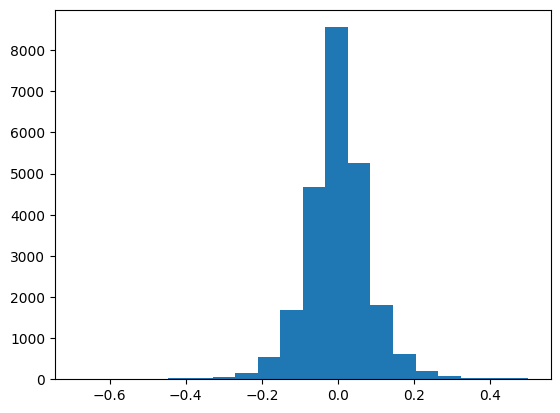

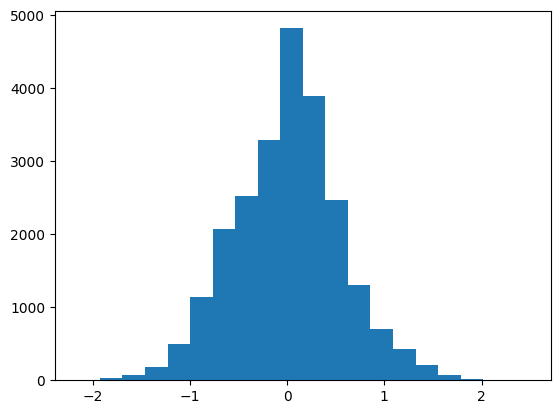

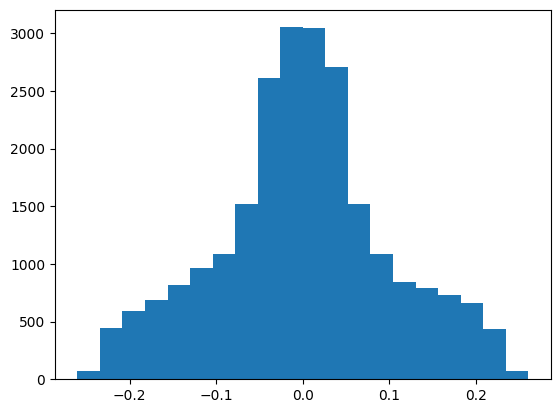

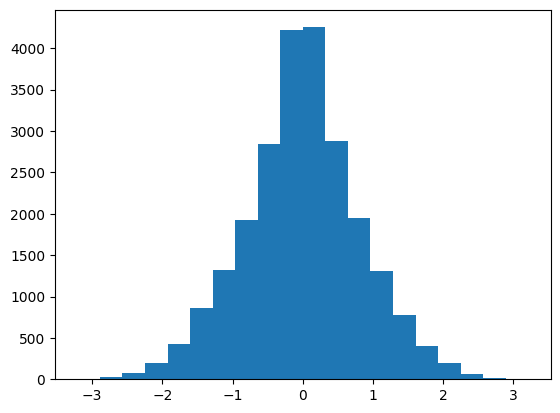

In [40]:
seen_observation = []
for _ in range(1000):
    seen_observation.append(env.reset()[0])
    done = False
    while not done:
        s, r, terminated, truncated, _ = env.step(env.action_space.sample())
        done = terminated or truncated
        seen_observation.append(s)
seen_observation = np.array(seen_observation)
for obs_i in range(env.observation_space.shape[0]):
    plt.hist(seen_observation[:, obs_i], bins=20)
    plt.show()

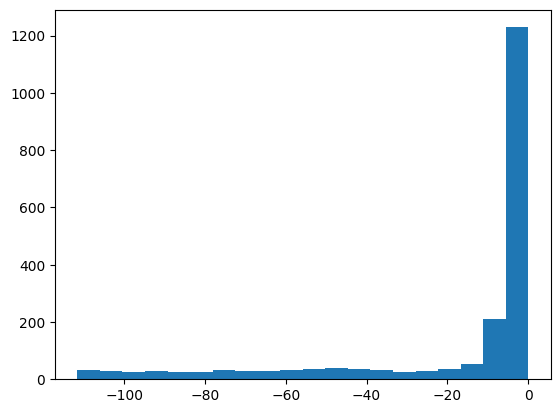

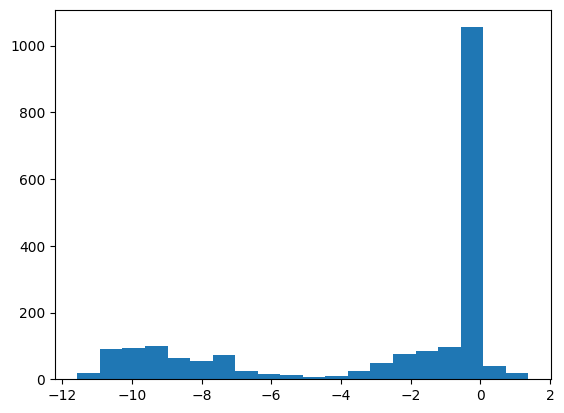

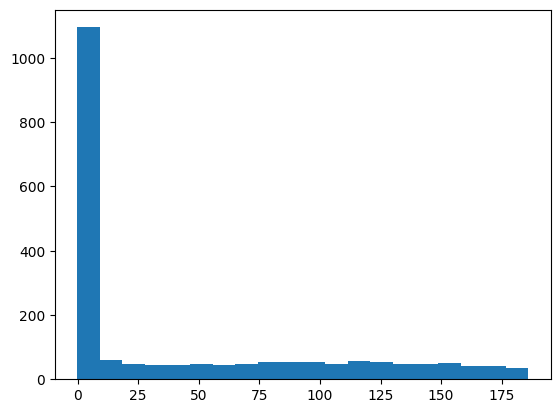

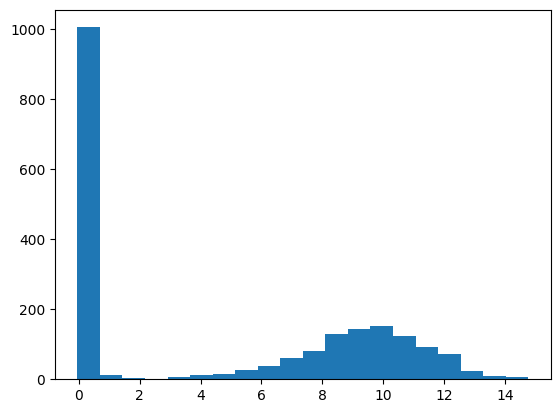

In [54]:
class Binarizer(ObservationWrapper):
    def observation(self, states):
        states = [round(state, 4) for state in states]
        return tuple(states)
    
env2 = Binarizer(gym.make('CartPole-v0').env)
env2.reset()

seen_observation = []
for _ in range(1000):
    seen_observation.append(env.reset()[0])
    done = False
    while not done:
        s, r, terminated, truncated, _ = env2.step(env.action_space.sample())
        done = terminated or truncated
        seen_observation.append(s)
seen_observation = np.array(seen_observation)
for obs_i in range(env2.observation_space.shape[0]):
    plt.hist(seen_observation[:, obs_i], bins=20)
    plt.show()
    